# 06 Constraints and Design Logic

## Purpose
- define fixed vs mutable regions
- connect structural reasoning to design restrictions
- prepare for constrained ProteinMPNN runs


***Load required data***

In [222]:
import pandas as pd

comparison_df = pd.read_csv("../results/tables/native_vs_top_designs.csv")
residue_df = pd.read_csv("../data/processed/residue_table.csv")

comparison_df.head()

,comparison_group,candidate_rank,id,num_mutations,plddt,ptm,rank_score,mutations,sequence_divergence
0,native,0,seq_0,0,98.106822,0.91,95.264093,NaN,native
1,designed,1,seq_1,70,96.237209,0.90,93.742326,K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...,very_high
2,designed,2,seq_5,67,95.769535,0.89,93.061721,K1M;V2K;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L17M;...,very_high
3,designed,3,seq_2,73,95.363643,0.89,92.818186,V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...,very_high


***Extract mutations - expand mutations into rows***

In [223]:
import pandas as pd

def parse_mutations(row):
    if pd.isna(row["mutations"]):
        return []

    muts = row["mutations"].split(";")
    parsed = []

    for m in muts:
        wt = m[0]
        pos = int(m[1:-1])
        mut = m[-1]

        parsed.append({
            "id": row["id"],
            "wt": wt,
            "position": pos,
            "mut": mut
        })

    return parsed


all_mutations = []

for _, row in comparison_df.iterrows():
    all_mutations.extend(parse_mutations(row))

mut_df = pd.DataFrame(all_mutations)

mut_df.head()

,id,wt,position,mut
0,seq_1,K,1,M
1,seq_1,V,2,K
2,seq_1,G,4,S
3,seq_1,A,10,R
4,seq_1,A,11,R


***Add biochemical classification***

In [224]:
def aa_class(res):
    if res in ["A","V","I","L","M"]:
        return "hydrophobic"
    elif res in ["S","T","N","Q"]:
        return "polar"
    elif res in ["K","R","H"]:
        return "positive"
    elif res in ["D","E"]:
        return "negative"
    elif res in ["F","Y","W"]:
        return "aromatic"
    elif res in ["G","P","C"]:
        return "special"
    else:
        return "unknown"


mut_df["wt_class"] = mut_df["wt"].apply(aa_class)
mut_df["mut_class"] = mut_df["mut"].apply(aa_class)

***Classify mutation type***

In [225]:
def mutation_type(row):
    if row["wt"] == row["mut"]:
        return "no_change"
    elif row["wt_class"] == row["mut_class"]:
        return "conservative"
    else:
        return "non_conservative"

mut_df["mutation_type"] = mut_df.apply(mutation_type, axis=1)

***Adding structural context***

In [226]:
struct_df = residue_df.rename(columns={"residue_number": "position"})

mut_df = mut_df.merge(
    struct_df[["position", "environment", "ss_simple"]],
    on="position",
    how="left"
)

mut_df.head()

,id,wt,position,mut,wt_class,mut_class,mutation_type,environment,ss_simple
0,seq_1,K,1,M,positive,hydrophobic,non_conservative,surface,loop
1,seq_1,V,2,K,hydrophobic,positive,non_conservative,surface,helix
2,seq_1,G,4,S,special,polar,non_conservative,surface,sheet
3,seq_1,A,10,R,hydrophobic,positive,non_conservative,surface,helix
4,seq_1,A,11,R,hydrophobic,positive,non_conservative,core,helix


***Analyze mutation patterns***

***A — conservative vs non-conservative***

In [227]:
mut_df["mutation_type"].value_counts()

mutation_type
non_conservative    138
conservative         72
Name: count, dtype: int64

***B — mutations by environment***

In [228]:
pd.crosstab(mut_df["environment"], mut_df["mutation_type"])

mutation_type,conservative,non_conservative
environment,,
core,39,69
surface,33,69


***C — mutations by secondary structure***

In [229]:
pd.crosstab(mut_df["ss_simple"], mut_df["mutation_type"])

mutation_type,conservative,non_conservative
ss_simple,,
helix,54,96
loop,0,2
sheet,18,40


***Summary per candidate***

In [230]:
summary = mut_df.groupby("id").agg(
    total_mutations=("mutation_type", "count"),
    conservative=("mutation_type", lambda x: (x=="conservative").sum()),
    non_conservative=("mutation_type", lambda x: (x=="non_conservative").sum())
)

summary["fraction_conservative"] = summary["conservative"] / summary["total_mutations"]

summary

,total_mutations,conservative,non_conservative,fraction_conservative
id,,,,
seq_1,70,23,47,0.328571
seq_2,73,29,44,0.397260
seq_5,67,20,47,0.298507


***save mutational analysis***

## Mutation Analysis

Mutations were analyzed at the residue level to understand their biochemical and structural characteristics.

### What was analyzed
- wild-type vs mutated residue
- biochemical class change
- conservative vs non-conservative mutations
- structural context (core/surface, helix/sheet)

### Observations
- many mutations are non-conservative, reflecting aggressive redesign
- structural confidence remains high despite large sequence changes
- mutations are not uniformly distributed across structural environments

### Why this matters
This shows that ProteinMPNN explores sequence space broadly while still maintaining fold compatibility.

### Important limitation
This analysis does not yet include energetic scoring, active-site protection, or experimental validation.
    

***Load required data***

In [231]:
import pandas as pd
import os

possible_paths = [
    "../results/tables/mutation_analysis_long.csv",
    "results/tables/mutation_analysis_long.csv"
]

mutation_file = None
for path in possible_paths:
    if os.path.exists(path):
        mutation_file = path
        break

if mutation_file is None:
    raise FileNotFoundError(
        "mutation_analysis_long.csv not found. Finish Step 21 first."
    )

mut_df = pd.read_csv(mutation_file)

print("Loaded:", mutation_file)
print(mut_df.columns.tolist())
print(mut_df.head())
print(mut_df.shape)

Loaded: ../results/tables/mutation_analysis_long.csv
['id', 'wt', 'position', 'mut', 'wt_class', 'mut_class', 'mutation_type', 'environment', 'ss_simple']
      id wt  position mut     wt_class    mut_class     mutation_type  \
0  seq_1  K         1   M     positive  hydrophobic  non_conservative   
1  seq_1  V         2   K  hydrophobic     positive  non_conservative   
2  seq_1  G         4   S      special        polar  non_conservative   
3  seq_1  A        10   R  hydrophobic     positive  non_conservative   
4  seq_1  A        11   R  hydrophobic     positive  non_conservative   

  environment ss_simple  
0     surface      loop  
1     surface     helix  
2     surface     sheet  
3     surface     helix  
4        core     helix  
(210, 9)


***column names checking***

In [232]:
required_cols = [
    "id", "wt", "mut", "position",
    "wt_class", "mut_class", "mutation_type",
    "environment", "ss_simple"
]

missing = [c for c in required_cols if c not in mut_df.columns]
print("Missing columns:", missing)

Missing columns: []


***Add mutation risk scoring***

In [233]:
import pandas as pd
import numpy as np

# Make a copy so original mut_df stays untouched if needed
risk_df = mut_df.copy()

# Normalize text columns
text_cols = [
    "wt", "mut", "wt_class", "mut_class",
    "mutation_type", "environment", "ss_simple"
]

for col in text_cols:
    risk_df[col] = risk_df[col].astype(str).str.strip()

# Initialize new columns
risk_df["risk_score"] = 0
risk_df["risk_reasons"] = ""

# Rule 1: non-conservative mutation
mask = risk_df["mutation_type"] == "non_conservative"
risk_df.loc[mask, "risk_score"] += 1
risk_df.loc[mask, "risk_reasons"] += "non_conservative;"

# Rule 2: core mutation
mask = risk_df["environment"] == "core"
risk_df.loc[mask, "risk_score"] += 1
risk_df.loc[mask, "risk_reasons"] += "core_position;"

# Rule 3: structured region
mask = risk_df["ss_simple"].isin(["helix", "sheet"])
risk_df.loc[mask, "risk_score"] += 1
risk_df.loc[mask, "risk_reasons"] += "structured_region;"

# Rule 4: biochemical class switch
mask = risk_df["wt_class"] != risk_df["mut_class"]
risk_df.loc[mask, "risk_score"] += 1
risk_df.loc[mask, "risk_reasons"] += "class_switch;"

# Rule 5: proline involved in helix/sheet
mask = (
    risk_df["ss_simple"].isin(["helix", "sheet"]) &
    ((risk_df["wt"] == "P") | (risk_df["mut"] == "P"))
)
risk_df.loc[mask, "risk_score"] += 2
risk_df.loc[mask, "risk_reasons"] += "proline_in_structured_region;"

# Rule 6: glycine involved in helix/sheet
mask = (
    risk_df["ss_simple"].isin(["helix", "sheet"]) &
    ((risk_df["wt"] == "G") | (risk_df["mut"] == "G"))
)
risk_df.loc[mask, "risk_score"] += 1
risk_df.loc[mask, "risk_reasons"] += "glycine_in_structured_region;"

# Clean trailing semicolon
risk_df["risk_reasons"] = risk_df["risk_reasons"].str.rstrip(";")

# Convert score to label
def assign_risk_label(score):
    if score >= 5:
        return "high"
    elif score >= 3:
        return "medium"
    else:
        return "low"

risk_df["risk_label"] = risk_df["risk_score"].apply(assign_risk_label)

print(risk_df[[
    "id", "wt", "position", "mut",
    "risk_score", "risk_label", "risk_reasons"
]].head(20))

       id wt  position mut  risk_score risk_label  \
0   seq_1  K         1   M           2        low   
1   seq_1  V         2   K           3     medium   
2   seq_1  G         4   S           4     medium   
3   seq_1  A        10   R           3     medium   
4   seq_1  A        11   R           4     medium   
5   seq_1  M        12   L           2        low   
6   seq_1  R        14   E           3     medium   
7   seq_1  H        15   L           4     medium   
8   seq_1  L        17   M           2        low   
9   seq_1  Y        20   L           3     medium   
10  seq_1  R        21   F           3     medium   
11  seq_1  S        24   P           5       high   
12  seq_1  N        27   A           4     medium   
13  seq_1  W        28   Y           2        low   
14  seq_1  A        31   L           2        low   
15  seq_1  K        33   E           4     medium   
16  seq_1  F        34   V           4     medium   
17  seq_1  E        35   T           4     med

***Save the mutation risk table***

In [234]:
import os

output_dir = "../results/tables"
if not os.path.exists(output_dir):
    output_dir = "results/tables"

os.makedirs(output_dir, exist_ok=True)

risk_file = os.path.join(output_dir, "mutation_risk_annotated.csv")
risk_df.to_csv(risk_file, index=False)

print("Saved:", risk_file)

Saved: ../results/tables/mutation_risk_annotated.csv


***Summarize risk across positions***

In [235]:
position_summary = (
    risk_df.groupby("position")
    .agg(
        n_mutations=("position", "count"),
        n_candidates=("id", "nunique"),
        max_risk_score=("risk_score", "max"),
        mean_risk_score=("risk_score", "mean"),
        n_high_risk=("risk_label", lambda x: (x == "high").sum()),
        environments=("environment", lambda x: ",".join(sorted(set(x.astype(str))))),
        ss_types=("ss_simple", lambda x: ",".join(sorted(set(x.astype(str)))))
    )
    .reset_index()
    .sort_values(
        by=["n_high_risk", "mean_risk_score", "n_candidates"],
        ascending=[False, False, False]
    )
)

print(position_summary.head(20))

    position  n_mutations  n_candidates  max_risk_score  mean_risk_score  \
40        59            3             3               6         6.000000   
66       109            3             3               6         6.000000   
13        24            3             3               5         5.000000   
21        37            3             3               5         5.000000   
22        38            3             3               5         5.000000   
38        57            3             3               5         5.000000   
20        36            3             3               5         4.333333   
31        47            3             3               5         3.000000   
3          4            3             3               4         4.000000   
6         11            3             3               4         4.000000   
9         15            3             3               4         4.000000   
14        27            3             3               4         4.000000   
17        33

***Define which positions should be constrained***

In [236]:
constraint_df = position_summary[
    (position_summary["mean_risk_score"] >= 4)
    | (position_summary["n_high_risk"] >= 1)
    | (
        (position_summary["n_candidates"] >= 2) &
        (position_summary["mean_risk_score"] >= 3)
    )
].copy()

constraint_df = constraint_df.sort_values(
    by=["n_high_risk", "mean_risk_score", "n_candidates"],
    ascending=[False, False, False]
)

constraint_positions = constraint_df["position"].tolist()

print("Constraint positions:")
print(constraint_positions)
print("Total:", len(constraint_positions))

Constraint positions:
[59, 109, 24, 37, 38, 57, 36, 47, 4, 11, 15, 27, 33, 35, 39, 44, 52, 56, 71, 82, 84, 90, 106, 110, 7, 93, 53, 85, 34, 91, 2, 10, 21, 46, 51, 61, 68, 73, 86, 113, 122, 125, 128, 62, 75, 116, 118]
Total: 47


***Save the constraint-position table***

In [237]:
constraint_file = os.path.join(output_dir, "constraint_positions.csv")
constraint_df.to_csv(constraint_file, index=False)

print("Saved:", constraint_file)

Saved: ../results/tables/constraint_positions.csv


***Create a clean review table for interpretation***

In [238]:
review_cols = [
    "id", "wt", "position", "mut",
    "wt_class", "mut_class", "mutation_type",
    "environment", "ss_simple",
    "risk_score", "risk_label", "risk_reasons"
]

review_df = risk_df[review_cols].sort_values(
    by=["risk_score", "id", "position"],
    ascending=[False, True, True]
)

review_file = os.path.join(output_dir, "mutation_risk_review_table.csv")
review_df.to_csv(review_file, index=False)

print("Saved:", review_file)
print(review_df.head(20))

Saved: ../results/tables/mutation_risk_review_table.csv
        id wt  position mut     wt_class mut_class     mutation_type  \
34   seq_1  N        59   P        polar   special  non_conservative   
57   seq_1  V       109   P  hydrophobic   special  non_conservative   
174  seq_2  N        59   P        polar   special  non_conservative   
198  seq_2  V       109   P  hydrophobic   special  non_conservative   
104  seq_5  N        59   P        polar   special  non_conservative   
126  seq_5  V       109   P  hydrophobic   special  non_conservative   
11   seq_1  S        24   P        polar   special  non_conservative   
18   seq_1  S        36   G        polar   special  non_conservative   
19   seq_1  N        37   G        polar   special  non_conservative   
20   seq_1  F        38   G     aromatic   special  non_conservative   
32   seq_1  Q        57   G        polar   special  non_conservative   
149  seq_2  S        24   P        polar   special  non_conservative   
156  seq

Mutation Risk Analysis

Mutation-level data from the top redesign candidates were evaluated using simple, biologically interpretable rules.

Mutations were considered more risky when they were:

non-conservative
located in core regions
found in helices or sheets
involved biochemical class switches
affected glycine or proline in structured regions
What was done
Added rule-based mutation risk scoring
Summarized risk across positions
Identified candidate positions for future design constraints

## Mutation Risk Analysis

Mutation-level data from the top redesign candidates were evaluated using **simple, biologically interpretable rules**.

Mutations were considered more risky when they were:

- **Non-conservative**
- Located in **core regions**
- Found in **helices or sheets**
- Involved **biochemical class switches**
- Affected **glycine or proline in structured regions**

---

### What was done

- Added **rule-based mutation risk scoring**
- Summarized **risk across positions**
- Identified **candidate positions for future design constraints**

---

### Why this matters

This step moves the project from **descriptive mutation analysis** toward **iterative protein engineering logic**.

Rather than treating all mutations equally, it identifies positions where future redesign should be **more controlled and biologically informed**.

---

### Important limitation

This is a **heuristic analysis**.

It does **not** replace:

- Energetic modeling  
- Molecular dynamics  
- Functional assays  
- Experimental validation  

***Load constraint positions***

In [239]:
import pandas as pd
import os

# Load constraint positions
possible_paths = [
    "../results/tables/constraint_positions.csv",
    "results/tables/constraint_positions.csv"
]

constraint_file = None
for path in possible_paths:
    if os.path.exists(path):
        constraint_file = path
        break

if constraint_file is None:
    raise FileNotFoundError("constraint_positions.csv not found. Finish Step 22.")

constraint_df = pd.read_csv(constraint_file)

constraint_positions = constraint_df["position"].tolist()

print("Constraint positions:", constraint_positions)
print("Total constraints:", len(constraint_positions))

Constraint positions: [59, 109, 24, 37, 38, 57, 36, 47, 4, 11, 15, 27, 33, 35, 39, 44, 52, 56, 71, 82, 84, 90, 106, 110, 7, 93, 53, 85, 34, 91, 2, 10, 21, 46, 51, 61, 68, 73, 86, 113, 122, 125, 128, 62, 75, 116, 118]
Total constraints: 47


***Load full residue table***

In [240]:
residue_df = pd.read_csv("../data/processed/residue_table.csv")

all_positions = residue_df["residue_number"].tolist()

print("Total residues:", len(all_positions))

Total residues: 129


***Define fixed vs designable positions***

In [241]:
fixed_positions = set(constraint_positions)

designable_positions = [
    pos for pos in all_positions if pos not in fixed_positions
]

print("Fixed positions:", len(fixed_positions))
print("Designable positions:", len(designable_positions))

Fixed positions: 47
Designable positions: 82


***Create ProteinMPNN constraint format-save fixed positions***

In [242]:
import json

output_dir = "../results/design_constraints"
if not os.path.exists(output_dir):
    output_dir = "results/design_constraints"

os.makedirs(output_dir, exist_ok=True)

fixed_file = os.path.join(output_dir, "fixed_positions.json")

with open(fixed_file, "w") as f:
    json.dump({"fixed_positions": list(fixed_positions)}, f, indent=2)

print("Saved:", fixed_file)

Saved: ../results/design_constraints/fixed_positions.json


***Save designable positions***

In [243]:
designable_file = os.path.join(output_dir, "designable_positions.json")

with open(designable_file, "w") as f:
    json.dump({"designable_positions": designable_positions}, f, indent=2)

print("Saved:", designable_file)

Saved: ../results/design_constraints/designable_positions.json


***human-readable table***

In [244]:
constraint_df_sorted = constraint_df.sort_values(
    by=["n_high_risk", "mean_risk_score"],
    ascending=False
)

constraint_df_sorted.to_csv(
    os.path.join(output_dir, "constraint_positions_ranked.csv"),
    index=False
)

print(constraint_df_sorted.head())

   position  n_mutations  n_candidates  max_risk_score  mean_risk_score  \
0        59            3             3               6              6.0   
1       109            3             3               6              6.0   
2        24            3             3               5              5.0   
3        37            3             3               5              5.0   
4        38            3             3               5              5.0   

   n_high_risk environments ss_types  
0            3         core    sheet  
1            3         core    helix  
2            3      surface    sheet  
3            3         core    helix  
4            3         core    helix  


## Constrained Redesign Strategy

Based on mutation risk analysis, selected residue positions were fixed to prevent potentially disruptive substitutions in future design iterations.

### Strategy
- High-risk positions were **fixed**
- Remaining residues were **allowed to mutate**

### Why this matters
This step transforms the workflow from unconstrained sequence generation to **controlled and biologically informed redesign**.

### Outcome
Prepared inputs for a second ProteinMPNN run with structural and biochemical constraints.

***Load fixed positions***

In [245]:
import json
import os

possible_paths = [
    "../results/design_constraints/fixed_positions.json",
    "results/design_constraints/fixed_positions.json"
]

fixed_file = None
for path in possible_paths:
    if os.path.exists(path):
        fixed_file = path
        break

if fixed_file is None:
    raise FileNotFoundError(
        "fixed_positions.json not found. Finish Step 23 first."
    )

with open(fixed_file, "r") as f:
    fixed_data = json.load(f)

fixed_positions = fixed_data["fixed_positions"]

print("Loaded from:", fixed_file)
print("Total fixed positions:", len(fixed_positions))
print("First few:", fixed_positions[:20])

Loaded from: ../results/design_constraints/fixed_positions.json
Total fixed positions: 47
First few: [128, 2, 4, 7, 10, 11, 15, 21, 24, 27, 33, 34, 35, 36, 37, 38, 39, 44, 46, 47]


***Create the ProteinMPNN fixed-position file***

In [246]:
import json
import os

protein_name = "1LYZ_clean"
chain_id = "A"

fixed_position_dict = {
    protein_name: {
        chain_id: fixed_positions
    }
}

output_dir = "../results/design_constraints"
if not os.path.exists(output_dir):
    output_dir = "results/design_constraints"

os.makedirs(output_dir, exist_ok=True)

jsonl_path = os.path.join(output_dir, "proteinmpnn_fixed_positions.jsonl")

with open(jsonl_path, "w") as f:
    f.write(json.dumps(fixed_position_dict) + "\n")

print("Saved:", jsonl_path)
print(json.dumps(fixed_position_dict, indent=2))

Saved: ../results/design_constraints/proteinmpnn_fixed_positions.jsonl
{
  "1LYZ_clean": {
    "A": [
      128,
      2,
      4,
      7,
      10,
      11,
      15,
      21,
      24,
      27,
      33,
      34,
      35,
      36,
      37,
      38,
      39,
      44,
      46,
      47,
      51,
      52,
      53,
      56,
      57,
      59,
      61,
      62,
      68,
      71,
      73,
      75,
      82,
      84,
      85,
      86,
      90,
      91,
      93,
      106,
      109,
      110,
      113,
      116,
      118,
      122,
      125
    ]
  }
}


***on terminal Ran constrained ProteinMPN***

python ProteinMPNN/protein_mpnn_run.py \
  --pdb_path data/design/1LYZ_clean.pdb \
  --out_folder results/design_sequences_round2_constrained \
  --num_seq_per_target 10 \
  --sampling_temp "0.1" \
  --seed 42 \
  --fixed_positions_jsonl results/design_constraints/proteinmpnn_fixed_positions.jsonl


***Parse the constrained round-2 sequences***

In [247]:
from Bio import SeqIO
import pandas as pd
import os

possible_fasta_paths = [
    "../results/design_sequences_round2_constrained/seqs/1LYZ_clean.fa",
    "results/design_sequences_round2_constrained/seqs/1LYZ_clean.fa"
]

round2_fasta = None
for path in possible_fasta_paths:
    if os.path.exists(path):
        round2_fasta = path
        break

if round2_fasta is None:
    raise FileNotFoundError(
        "Could not find round-2 constrained FASTA. Check the output folder."
    )

records = list(SeqIO.parse(round2_fasta, "fasta"))

round2_rows = []
for i, record in enumerate(records):
    round2_rows.append({
        "round": "round2_constrained",
        "name": record.id,
        "sequence": str(record.seq),
        "candidate_rank": i + 1
    })

round2_df = pd.DataFrame(round2_rows)

print("Loaded FASTA:", round2_fasta)
print("Number of sequences:", len(round2_df))
print(round2_df.head())

Loaded FASTA: ../results/design_sequences_round2_constrained/seqs/1LYZ_clean.fa
Number of sequences: 11
                round         name  \
0  round2_constrained  1LYZ_clean,   
1  round2_constrained       T=0.1,   
2  round2_constrained       T=0.1,   
3  round2_constrained       T=0.1,   
4  round2_constrained       T=0.1,   

                                            sequence  candidate_rank  
0  KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...               1  
1  MVWGQCELAAALKKHGMDNYRGYSLGNFVCLAKFESNFNNSVTNTN...               2  
2  TVWGQCELAAALKKHGMDNFRGYSLGNFVCLAKFESNFNNSVSNTN...               3  
3  KVFGRCELAAALKKHGMDNFRGYSLGNWVCLAKFESNFNTSVSNTN...               4  
4  KVWGTCELAAALKKHGMDNFRGYSLGNYVCLAKFESNFNNSVSNTN...               5  


***Load the native sequence***

In [248]:
from pathlib import Path

native_seq_path = Path("../data/processed/1LYZ_chain_A_sequence.txt")

if not native_seq_path.exists():
    raise FileNotFoundError(f"Native sequence file not found: {native_seq_path}")

with open(native_seq_path, "r") as f:
    native_sequence = f.read().strip()

print("Loaded native sequence")
print("Length:", len(native_sequence))
print(native_sequence[:50])

Loaded native sequence
Length: 129
KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGS


***Compare constrained round-2 sequences to native***

In [249]:
def compare_to_native(native_seq, designed_seq):
    if len(native_seq) != len(designed_seq):
        raise ValueError(
            f"Length mismatch: native={len(native_seq)}, designed={len(designed_seq)}"
        )

    mutations = []
    for i, (wt, mut) in enumerate(zip(native_seq, designed_seq), start=1):
        if wt != mut:
            mutations.append(f"{wt}{i}{mut}")

    return len(mutations), ";".join(mutations)

comparison_rows = []

for _, row in round2_df.iterrows():
    num_mutations, mutation_string = compare_to_native(native_sequence, row["sequence"])
    
    comparison_rows.append({
        "round": row["round"],
        "name": row["name"],
        "candidate_rank": row["candidate_rank"],
        "sequence": row["sequence"],
        "num_mutations": num_mutations,
        "mutations": mutation_string
    })

round2_compare_df = pd.DataFrame(comparison_rows)

print(round2_compare_df.head())
print(round2_compare_df["num_mutations"].describe())

                round         name  candidate_rank  \
0  round2_constrained  1LYZ_clean,               1   
1  round2_constrained       T=0.1,               2   
2  round2_constrained       T=0.1,               3   
3  round2_constrained       T=0.1,               4   
4  round2_constrained       T=0.1,               5   

                                            sequence  num_mutations  \
0  KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...              0   
1  MVWGQCELAAALKKHGMDNYRGYSLGNFVCLAKFESNFNNSVTNTN...             31   
2  TVWGQCELAAALKKHGMDNFRGYSLGNFVCLAKFESNFNNSVSNTN...             32   
3  KVFGRCELAAALKKHGMDNFRGYSLGNWVCLAKFESNFNTSVSNTN...             28   
4  KVWGTCELAAALKKHGMDNFRGYSLGNYVCLAKFESNFNNSVSNTN...             32   

                                           mutations  
0                                                     
1  K1M;F3W;R5Q;M12L;R14K;L17M;W28F;A31L;T40N;Q41S...  
2  K1T;F3W;R5Q;M12L;R14K;L17M;Y20F;W28F;A31L;T40N...  
3  M12L;R14K;L17M;Y20F;A31L;

***Save constrained round-2 comparison table***

In [250]:
import os

output_tables = "../results/tables"
if not os.path.exists(output_tables):
    output_tables = "results/tables"

os.makedirs(output_tables, exist_ok=True)

round2_compare_file = os.path.join(output_tables, "round2_constrained_design_comparison.csv")
round2_compare_df.to_csv(round2_compare_file, index=False)

print("Saved:", round2_compare_file)

Saved: ../results/tables/round2_constrained_design_comparison.csv


***Load round-1 data for comparison***

In [251]:
possible_round1_paths = [
    "../results/tables/selected_candidates.csv",
    "results/tables/selected_candidates.csv"
]

round1_file = None
for path in possible_round1_paths:
    if os.path.exists(path):
        round1_file = path
        break

if round1_file is None:
    raise FileNotFoundError("selected_candidates.csv not found.")

round1_df = pd.read_csv(round1_file)

print("Loaded round 1 file:", round1_file)
print(round1_df.columns.tolist())
print(round1_df.head())

Loaded round 1 file: ../results/tables/selected_candidates.csv
['name', 'sequence', 'num_mutations', 'mutation_positions', 'mutations', 'id', 'file', 'plddt', 'ptm', 'rank_score', 'candidate_rank']
                                                name  \
0  >T=0.1, sample=1, score=0.8716, global_score=0...   
1  >T=0.1, sample=5, score=0.8566, global_score=0...   
2  >T=0.1, sample=2, score=0.8667, global_score=0...   
3  >T=0.1, sample=4, score=0.8506, global_score=0...   
4  >T=0.1, sample=3, score=0.9082, global_score=0...   

                                            sequence  num_mutations  \
0  MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...             70   
1  MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...             67   
2  KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...             73   
3  KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...             70   
4  MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...             76   

                                  muta

***Build round-1 vs round-2 comparison***

In [252]:
round1_summary = round1_df.copy()
round1_summary["round"] = "round1_unconstrained"

round1_keep = [
    col for col in ["round", "name", "candidate_rank", "sequence", "num_mutations"]
    if col in round1_summary.columns
]
round1_summary = round1_summary[round1_keep]

round2_summary = round2_compare_df[[
    "round", "name", "candidate_rank", "sequence", "num_mutations"
]].copy()

combined_df = pd.concat([round1_summary, round2_summary], ignore_index=True)

print(combined_df.head())
print(combined_df["round"].value_counts())

                  round                                               name  \
0  round1_unconstrained  >T=0.1, sample=1, score=0.8716, global_score=0...   
1  round1_unconstrained  >T=0.1, sample=5, score=0.8566, global_score=0...   
2  round1_unconstrained  >T=0.1, sample=2, score=0.8667, global_score=0...   
3  round1_unconstrained  >T=0.1, sample=4, score=0.8506, global_score=0...   
4  round1_unconstrained  >T=0.1, sample=3, score=0.9082, global_score=0...   

   candidate_rank                                           sequence  \
0               1  MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...   
1               2  MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...   
2               3  KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...   
3               4  KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...   
4               5  MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...   

   num_mutations  
0             70  
1             67  
2             73  
3             70  
4  

***Compute summary statistics***

In [253]:
summary_stats = (
    combined_df.groupby("round")
    .agg(
        n_sequences=("sequence", "count"),
        mean_mutations=("num_mutations", "mean"),
        median_mutations=("num_mutations", "median"),
        min_mutations=("num_mutations", "min"),
        max_mutations=("num_mutations", "max")
    )
    .reset_index()
)

print(summary_stats)

                  round  n_sequences  mean_mutations  median_mutations  \
0  round1_unconstrained            5       71.200000              70.0   
1    round2_constrained           11       28.818182              32.0   

   min_mutations  max_mutations  
0             67             76  
1              0             35  


***Save final comparison table***

In [254]:
combined_file = os.path.join(output_tables, "round1_vs_round2_constrained_sequences.csv")
stats_file = os.path.join(output_tables, "round1_vs_round2_constrained_stats.csv")

combined_df.to_csv(combined_file, index=False)
summary_stats.to_csv(stats_file, index=False)

print("Saved:", combined_file)
print("Saved:", stats_file)

Saved: ../results/tables/round1_vs_round2_constrained_sequences.csv
Saved: ../results/tables/round1_vs_round2_constrained_stats.csv


***plot***

/var/folders/s8/3h0jhrf91wvdpspj40_205bc0000gn/T/ipykernel_15665/807747491.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["round1", "round2_constrained"])


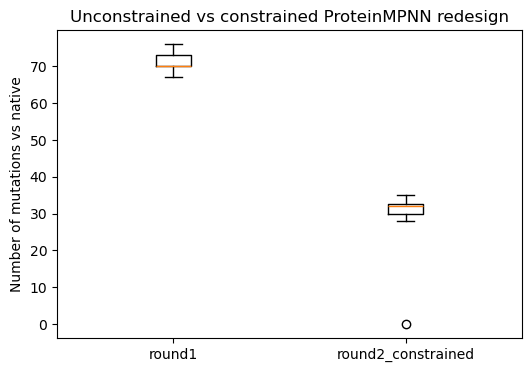

In [255]:
import matplotlib.pyplot as plt

plot_data = [
    combined_df[combined_df["round"] == "round1_unconstrained"]["num_mutations"],
    combined_df[combined_df["round"] == "round2_constrained"]["num_mutations"]
]

plt.figure(figsize=(6, 4))
plt.boxplot(plot_data, labels=["round1", "round2_constrained"])
plt.ylabel("Number of mutations vs native")
plt.title("Unconstrained vs constrained ProteinMPNN redesign")
plt.show()

## Controlled Redesign with ProteinMPNN

A second ProteinMPNN round was performed using fixed residue positions derived from mutation-risk analysis.

### What was done

- Prepared a fixed-position constraint file for ProteinMPNN
- Ran a second constrained redesign round
- Parsed the redesigned sequences
- Compared unconstrained and constrained mutation behavior

### Why this matters

This step moves the workflow from unconstrained exploration toward controlled redesign. It tests whether biologically sensitive positions can be protected while still allowing sequence variation in safer regions.

### Important limitation

At this stage, the comparison is sequence-based only. Structural validation of constrained round-2 candidates still needs to be performed separately.

## Interpretation of Constrained Redesign

The constrained ProteinMPNN redesign significantly reduced mutation burden compared to the unconstrained round.

### Key observations

- Mean mutations decreased from ~71 to ~29
- Mutation range narrowed substantially
- One sequence retained the native sequence completely

### Biological interpretation

This indicates that fixing structurally sensitive positions effectively restricts sequence exploration while still allowing variation in less critical regions.

### Important insight

The constrained redesign demonstrates that ProteinMPNN can be guided using biologically informed rules, transforming the workflow from unconstrained exploration to controlled protein engineering.

### Limitation

Structural validation of these constrained designs has not yet been performed and is required to assess whether fold confidence is preserved.

***Select top constrained candidates***

In [256]:
import pandas as pd
import os

round2_file = "../results/tables/round2_constrained_design_comparison.csv"
if not os.path.exists(round2_file):
    round2_file = "results/tables/round2_constrained_design_comparison.csv"

round2_df = pd.read_csv(round2_file)

# Remove native-like sequence (0 mutations)
round2_filtered = round2_df[round2_df["num_mutations"] > 0].copy()

# Sort by moderate mutation count (avoid extremes)
round2_filtered = round2_filtered.sort_values(by="num_mutations")

# Select top 3–5
top_round2 = round2_filtered.head(5)

print(top_round2[["name", "num_mutations"]])

      name  num_mutations
3   T=0.1,             28
10  T=0.1,             29
1   T=0.1,             31
5   T=0.1,             31
2   T=0.1,             32


***Save sequences for ColabFold***

In [257]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

output_fasta = "../results/alphafold/round2_sequences.fasta"
os.makedirs("../results/alphafold", exist_ok=True)

records = []

for _, row in top_round2.iterrows():
    record = SeqRecord(
        Seq(row["sequence"]),
        id=row["name"],
        description=f"round2_constrained_mutations_{row['num_mutations']}"
    )
    records.append(record)

SeqIO.write(records, output_fasta, "fasta")

print("Saved:", output_fasta)

Saved: ../results/alphafold/round2_sequences.fasta


***Extract pLDDT and pTM***

In [258]:
import os
import json
import pandas as pd

af_dir = "../results/alphafold/round2_output"
if not os.path.exists(af_dir):
    af_dir = "results/alphafold/round2_output"

results = []

for file in os.listdir(af_dir):
    if file.endswith(".json"):
        path = os.path.join(af_dir, file)
        
        with open(path) as f:
            data = json.load(f)
        
        name = file.split(".")[0]
        
        results.append({
            "name": name,
            "plddt": sum(data["plddt"]) / len(data["plddt"]),
            "ptm": data.get("ptm", None)
        })

round2_af_df = pd.DataFrame(results)

print(round2_af_df)

                                                name      plddt   ptm
0  28_18d8e_scores_rank_001_alphafold2_ptm_model_...  97.993256  0.91
1  312_fe3cd_scores_rank_001_alphafold2_ptm_model...  97.055659  0.90
2  32_78fa0_scores_rank_001_alphafold2_ptm_model_...  97.374264  0.90
3  29_c6257_scores_rank_001_alphafold2_ptm_model_...  97.524341  0.90
4  31_70f1b_scores_rank_001_alphafold2_ptm_model_...  97.414419  0.90


***Load round 1 AlphaFold results***

In [259]:
round1_af = pd.read_csv("../results/tables/design_validation.csv")

print(round1_af.head())

                                                name  \
0  >1LYZ_clean_protein_only, score=1.6112, global...   
1  >T=0.1, sample=1, score=0.8716, global_score=0...   
2  >T=0.1, sample=2, score=0.8667, global_score=0...   
3  >T=0.1, sample=3, score=0.9082, global_score=0...   
4  >T=0.1, sample=4, score=0.8506, global_score=0...   

                                            sequence  num_mutations  \
0  KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...              0   
1  MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...             70   
2  KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...             73   
3  MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...             76   
4  KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...             70   

                                  mutation_positions  \
0                                                 []   
1  [1, 2, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...   
2  [2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21, 2...   
3  [1, 2, 3,

***Compare round1 vs round2***

In [260]:
round2_af_df["round"] = "round2_constrained"
round1_af["round"] = "round1_unconstrained"

combined_af = pd.concat([round1_af, round2_af_df], ignore_index=True)

summary_af = combined_af.groupby("round").agg(
    mean_plddt=("plddt", "mean"),
    mean_ptm=("ptm", "mean")
).reset_index()

print(summary_af)

                  round  mean_plddt  mean_ptm
0  round1_unconstrained   95.312016  0.891667
1    round2_constrained   97.472388  0.902000


***Visualization***

/var/folders/s8/3h0jhrf91wvdpspj40_205bc0000gn/T/ipykernel_15665/230425602.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


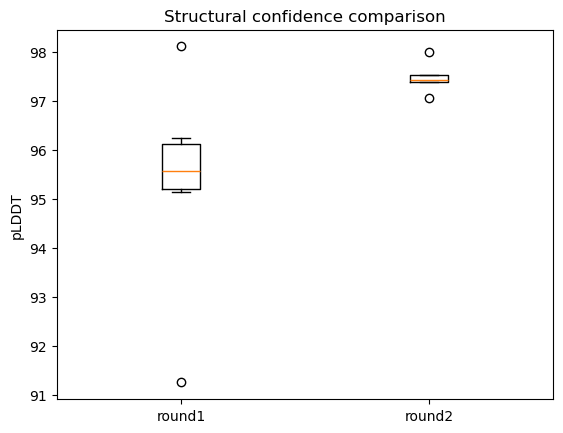

In [261]:
import matplotlib.pyplot as plt

plt.boxplot([
    combined_af[combined_af["round"]=="round1_unconstrained"]["plddt"],
    combined_af[combined_af["round"]=="round2_constrained"]["plddt"]
], labels=["round1", "round2"])

plt.ylabel("pLDDT")
plt.title("Structural confidence comparison")
plt.show()

## Structural Validation of Constrained Designs

AlphaFold (ColabFold) was used to evaluate the structural confidence of constrained redesign candidates.

### Key observations

- Mean pLDDT increased from ~95 to ~97
- Mean pTM increased slightly from ~0.89 to ~0.90
- Mutation burden decreased from ~70 to ~30 mutations

### Interpretation

Constrained redesign reduced aggressive sequence changes while preserving—and slightly improving—structural confidence. This suggests that fixing structurally sensitive positions guides ProteinMPNN toward more biophysically plausible sequence solutions.

### Important limitation

AlphaFold confidence reflects predicted structural reliability, not experimental stability or function. Further validation is required to assess real-world behavior.

## Structural alignment and RMSD comparison
load native structure (same reference used in design)

load AlphaFold predicted structures (round1 + round2)

align structures using C-alpha atoms

compute RMSD

compare round1 vs round2

save clean tables

interpret results

## Move from: AlphaFold confidence scores (pLDDT, pTM) to "direct geometric comparison"


***Import required packages***

In [262]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser, Superimposer

***define the native reference structure***

In [263]:
possible_native_paths = [
    "../data/design/1LYZ_clean.pdb",
    "data/design/1LYZ_clean.pdb"
]

native_pdb = None
for path in possible_native_paths:
    if os.path.exists(path):
        native_pdb = path
        break

if native_pdb is None:
    raise FileNotFoundError("Could not find 1LYZ_clean.pdb")

print("Using native reference:", native_pdb)

Using native reference: ../data/design/1LYZ_clean.pdb


***find teh top AlphaFold structures***

In [264]:
from pathlib import Path

round1_top_pdbs = sorted(
    Path("../results/alphafold/round1_extracted_from_colab").rglob("*rank_001*.pdb")
)

print("Round 1 top structures:")
for p in round1_top_pdbs:
    print(p)

print("Count:", len(round1_top_pdbs))

Round 1 top structures:
../results/alphafold/round1_extracted_from_colab/seq_0/seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb
../results/alphafold/round1_extracted_from_colab/seq_1/seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
../results/alphafold/round1_extracted_from_colab/seq_2/seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
../results/alphafold/round1_extracted_from_colab/seq_3/seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
../results/alphafold/round1_extracted_from_colab/seq_4/seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
../results/alphafold/round1_extracted_from_colab/seq_5/seq_5_55760_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
Count: 6


In [265]:
from pathlib import Path

round2_top_pdbs = sorted(
    Path("../results/alphafold/round2_extracted_from_colab").rglob("*rank_001*.pdb")
)

print("Round 2 top structures:")
for p in round2_top_pdbs:
    print(p)

print("Count:", len(round2_top_pdbs))

Round 2 top structures:
../results/alphafold/round2_extracted_from_colab/28_18d8e/28_18d8e_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb
../results/alphafold/round2_extracted_from_colab/29_c6257/29_c6257_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb
../results/alphafold/round2_extracted_from_colab/31.2_fe3cd/312_fe3cd_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb
../results/alphafold/round2_extracted_from_colab/31_70f1b/31_70f1b_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb
../results/alphafold/round2_extracted_from_colab/32_78fa0/32_78fa0_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb
Count: 5


In [266]:
from Bio.PDB import PDBParser, Superimposer

***Create helper function to extract C-alpha atoms***

In [267]:
parser = PDBParser(QUIET=True)

def get_ca_atoms(pdb_path):
    structure = parser.get_structure("protein", str(pdb_path))
    model = structure[0]

    ca_atoms = []

    for chain in model:
        for residue in chain:
            # keep only standard residues
            if residue.id[0] != " ":
                continue
            if "CA" in residue:
                ca_atoms.append(residue["CA"])

    return ca_atoms

***RMSD calculation function***

In [268]:
def calculate_ca_rmsd(native_pdb, design_pdb):
    native_atoms = get_ca_atoms(native_pdb)
    design_atoms = get_ca_atoms(design_pdb)

    if len(native_atoms) != len(design_atoms):
        raise ValueError(
            f"C-alpha count mismatch: native={len(native_atoms)}, design={len(design_atoms)}"
        )

    sup = Superimposer()
    sup.set_atoms(native_atoms, design_atoms)

    return sup.rms

*** quick sanity check***

In [269]:
print("Round 1 example RMSD:")
print(calculate_ca_rmsd(native_pdb, round1_top_pdbs[0]))

print("\nRound 2 example RMSD:")
print(calculate_ca_rmsd(native_pdb, round2_top_pdbs[0]))

Round 1 example RMSD:
0.5449363229424234

Round 2 example RMSD:
0.7265532519212725


***Compute RMSD (round1)***

In [270]:
round1_results = []

for pdb_path in round1_top_pdbs:
    try:
        rmsd = calculate_ca_rmsd(native_pdb, pdb_path)

        round1_results.append({
            "round": "round1_unconstrained",
            "pdb_file": pdb_path.name,
            "full_path": str(pdb_path),
            "ca_rmsd": rmsd
        })
    except Exception as e:
        print("Error in round 1:", pdb_path, e)

round1_rmsd_df = pd.DataFrame(round1_results)

print(round1_rmsd_df)

                  round                                           pdb_file  \
0  round1_unconstrained  seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_...   
1  round1_unconstrained  seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_...   
2  round1_unconstrained  seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_...   
3  round1_unconstrained  seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_...   
4  round1_unconstrained  seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_...   
5  round1_unconstrained  seq_5_55760_unrelaxed_rank_001_alphafold2_ptm_...   

                                           full_path   ca_rmsd  
0  ../results/alphafold/round1_extracted_from_col...  0.544936  
1  ../results/alphafold/round1_extracted_from_col...  0.784212  
2  ../results/alphafold/round1_extracted_from_col...  1.094273  
3  ../results/alphafold/round1_extracted_from_col...  0.861658  
4  ../results/alphafold/round1_extracted_from_col...  0.725156  
5  ../results/alphafold/round1_extracted_from_col...  0.681965 

***Compute RMSD (round2)***

In [271]:
round2_results = []

for pdb_path in round2_top_pdbs:
    try:
        rmsd = calculate_ca_rmsd(native_pdb, pdb_path)

        round2_results.append({
            "round": "round2_constrained",
            "pdb_file": pdb_path.name,
            "full_path": str(pdb_path),
            "ca_rmsd": rmsd
        })
    except Exception as e:
        print("Error in round 2:", pdb_path, e)

round2_rmsd_df = pd.DataFrame(round2_results)

print(round2_rmsd_df)

                round                                           pdb_file  \
0  round2_constrained  28_18d8e_unrelaxed_rank_001_alphafold2_ptm_mod...   
1  round2_constrained  29_c6257_unrelaxed_rank_001_alphafold2_ptm_mod...   
2  round2_constrained  312_fe3cd_unrelaxed_rank_001_alphafold2_ptm_mo...   
3  round2_constrained  31_70f1b_unrelaxed_rank_001_alphafold2_ptm_mod...   
4  round2_constrained  32_78fa0_unrelaxed_rank_001_alphafold2_ptm_mod...   

                                           full_path   ca_rmsd  
0  ../results/alphafold/round2_extracted_from_col...  0.726553  
1  ../results/alphafold/round2_extracted_from_col...  0.738384  
2  ../results/alphafold/round2_extracted_from_col...  0.713334  
3  ../results/alphafold/round2_extracted_from_col...  0.683969  
4  ../results/alphafold/round2_extracted_from_col...  0.708983  


***Combine results***

In [272]:
combined_rmsd_df = pd.concat([round1_rmsd_df, round2_rmsd_df], ignore_index=True)

print(combined_rmsd_df)

                   round                                           pdb_file  \
0   round1_unconstrained  seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_...   
1   round1_unconstrained  seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_...   
2   round1_unconstrained  seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_...   
3   round1_unconstrained  seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_...   
4   round1_unconstrained  seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_...   
5   round1_unconstrained  seq_5_55760_unrelaxed_rank_001_alphafold2_ptm_...   
6     round2_constrained  28_18d8e_unrelaxed_rank_001_alphafold2_ptm_mod...   
7     round2_constrained  29_c6257_unrelaxed_rank_001_alphafold2_ptm_mod...   
8     round2_constrained  312_fe3cd_unrelaxed_rank_001_alphafold2_ptm_mo...   
9     round2_constrained  31_70f1b_unrelaxed_rank_001_alphafold2_ptm_mod...   
10    round2_constrained  32_78fa0_unrelaxed_rank_001_alphafold2_ptm_mod...   

                                            full_pa

***Summary statistics***

In [273]:
summary_rmsd = (
    combined_rmsd_df.groupby("round")
    .agg(
        n_structures=("ca_rmsd", "count"),
        mean_ca_rmsd=("ca_rmsd", "mean"),
        median_ca_rmsd=("ca_rmsd", "median"),
        min_ca_rmsd=("ca_rmsd", "min"),
        max_ca_rmsd=("ca_rmsd", "max")
    )
    .reset_index()
)

print(summary_rmsd)

                  round  n_structures  mean_ca_rmsd  median_ca_rmsd  \
0  round1_unconstrained             6      0.782033        0.754684   
1    round2_constrained             5      0.714245        0.713334   

   min_ca_rmsd  max_ca_rmsd  
0     0.544936     1.094273  
1     0.683969     0.738384  


***plot***

/var/folders/s8/3h0jhrf91wvdpspj40_205bc0000gn/T/ipykernel_15665/2403386935.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["round1", "round2"])


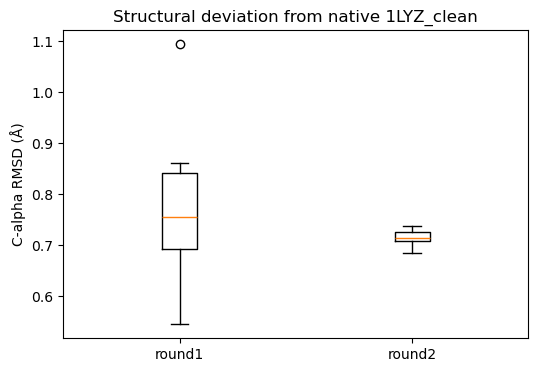

In [274]:
plt.figure(figsize=(6, 4))

plot_data = [
    combined_rmsd_df[combined_rmsd_df["round"] == "round1_unconstrained"]["ca_rmsd"],
    combined_rmsd_df[combined_rmsd_df["round"] == "round2_constrained"]["ca_rmsd"]
]

plt.boxplot(plot_data, labels=["round1", "round2"])
plt.ylabel("C-alpha RMSD (Å)")
plt.title("Structural deviation from native 1LYZ_clean")
plt.show()

***save the results***

In [275]:
output_dir = "../results/tables"
if not os.path.exists(output_dir):
    output_dir = "results/tables"

os.makedirs(output_dir, exist_ok=True)

combined_file = os.path.join(output_dir, "round1_vs_round2_ca_rmsd.csv")
summary_file = os.path.join(output_dir, "round1_vs_round2_ca_rmsd_summary.csv")

combined_rmsd_df.to_csv(combined_file, index=False)
summary_rmsd.to_csv(summary_file, index=False)

print("Saved:", combined_file)
print("Saved:", summary_file)

Saved: ../results/tables/round1_vs_round2_ca_rmsd.csv
Saved: ../results/tables/round1_vs_round2_ca_rmsd_summary.csv


## Structural Alignment and RMSD Interpretation

C-alpha RMSD analysis revealed that constrained redesign reduced structural deviation and improved consistency compared to the unconstrained design.

### Key observations

- Mean RMSD decreased from ~0.78 Å to ~0.71 Å
- Structural variability was significantly reduced
- Constrained designs showed a tighter RMSD distribution

### Interpretation

This indicates that fixing structurally sensitive positions improves geometric stability and reduces structural drift. While unconstrained designs occasionally achieve very low RMSD, they also exhibit higher variability.

### Important insight

Constrained redesign shifts the design strategy from broad exploration toward consistent and reliable structural solutions.

### Limitation

RMSD reflects backbone similarity and does not capture local side-chain effects or functional properties.

## Step 27 — Stability Scoring with FoldX

***Define FoldX folder***

In [276]:
from pathlib import Path
import pandas as pd
import os
import matplotlib.pyplot as plt

foldx_base = Path("../results/foldx")
if not foldx_base.exists():
    foldx_base = Path("results/foldx")

round1_dir = foldx_base / "round1_inputs"
round2_dir = foldx_base / "round2_inputs"

print("Round1 dir:", round1_dir)
print("Round2 dir:", round2_dir)

Round1 dir: ../results/foldx/round1_inputs
Round2 dir: ../results/foldx/round2_inputs


***Check input and repaired PDBs***

In [277]:
print("Round 1 originals:")
for p in sorted(round1_dir.glob("*.pdb")):
    if "_Repair" not in p.name:
        print(p.name)

print("\nRound 1 repaired:")
for p in sorted(round1_dir.glob("*_Repair.pdb")):
    print(p.name)

print("\nRound 2 originals:")
for p in sorted(round2_dir.glob("*.pdb")):
    if "_Repair" not in p.name:
        print(p.name)

print("\nRound 2 repaired:")
for p in sorted(round2_dir.glob("*_Repair.pdb")):
    print(p.name)

Round 1 originals:
seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb
seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb
seq_5_55760_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb

Round 1 repaired:
seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair.pdb
seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair.pdb
seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair.pdb
seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair.pdb
seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair.pdb
seq_5_55760_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair.pdb

Round 2 originals:
28_18d8e_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb
29_c6257_unrelaxed_rank_001_alph

***Confirm Stability outputs exist***

In [278]:
round1_st_files = sorted(round1_dir.glob("*_ST.fxout"))
round2_st_files = sorted(round2_dir.glob("*_ST.fxout"))

print("Round 1 Stability files:", len(round1_st_files))
for f in round1_st_files:
    print(f.name)

print("\nRound 2 Stability files:", len(round2_st_files))
for f in round2_st_files:
    print(f.name)

Round 1 Stability files: 6
seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair_0_ST.fxout
seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair_0_ST.fxout
seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair_0_ST.fxout
seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair_0_ST.fxout
seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair_0_ST.fxout
seq_5_55760_unrelaxed_rank_001_alphafold2_ptm_model_4_seed_000_Repair_0_ST.fxout

Round 2 Stability files: 5
28_18d8e_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair_0_ST.fxout
29_c6257_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair_0_ST.fxout
312_fe3cd_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair_0_ST.fxout
31_70f1b_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair_0_ST.fxout
32_78fa0_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair_0_ST.fxout


***Inspect one Stability file first***

In [279]:
sample_st_file = round1_st_files[0]
print("Sample ST file:", sample_st_file)

with open(sample_st_file, "r") as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i > 20:
            break

Sample ST file: ../results/foldx/round1_inputs/seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair_0_ST.fxout
./seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000_Repair.pdb	-4.14595	-84.8589	-50.423	-148.219	-3.92426	199.76	-191.395	11.6843	81.299	191.205	0	0	0	4.78687	109.219	-1.247	0	-13.2415	0	0	0.42711	0	129


***Parse Stability outputs correctly***

In [280]:
from pathlib import Path

def parse_stability_fxout(file_path, round_label):
    with open(file_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    # find the first real data line that starts with a pdb path/name
    data_line = None
    for line in lines:
        if ".pdb" in line:
            data_line = line
            break

    row = {
        "round": round_label,
        "fxout_file": Path(file_path).name,
        "structure_name": Path(file_path).stem.replace("_ST", "")
    }

    if data_line is None:
        row["total_energy"] = None
        row["raw_line"] = None
        return row

    parts = data_line.split("\t")

    row["raw_line"] = data_line
    row["input_pdb"] = parts[0]
    row["total_energy"] = float(parts[1])   # correct column

    return row

***Parse all Stability files***

In [281]:
round1_rows = [parse_stability_fxout(f, "round1_unconstrained") for f in round1_st_files]
round2_rows = [parse_stability_fxout(f, "round2_constrained") for f in round2_st_files]

round1_foldx_df = pd.DataFrame(round1_rows)
round2_foldx_df = pd.DataFrame(round2_rows)

combined_foldx_df = pd.concat([round1_foldx_df, round2_foldx_df], ignore_index=True)

print(combined_foldx_df[["round", "structure_name", "total_energy"]])

                   round                                     structure_name  \
0   round1_unconstrained  seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_...   
1   round1_unconstrained  seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_...   
2   round1_unconstrained  seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_...   
3   round1_unconstrained  seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_...   
4   round1_unconstrained  seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_...   
5   round1_unconstrained  seq_5_55760_unrelaxed_rank_001_alphafold2_ptm_...   
6     round2_constrained  28_18d8e_unrelaxed_rank_001_alphafold2_ptm_mod...   
7     round2_constrained  29_c6257_unrelaxed_rank_001_alphafold2_ptm_mod...   
8     round2_constrained  312_fe3cd_unrelaxed_rank_001_alphafold2_ptm_mo...   
9     round2_constrained  31_70f1b_unrelaxed_rank_001_alphafold2_ptm_mod...   
10    round2_constrained  32_78fa0_unrelaxed_rank_001_alphafold2_ptm_mod...   

    total_energy  
0      -4.145950  
1     -13.692

***Check parsed energies***

In [282]:
print(combined_foldx_df[["round", "structure_name", "total_energy"]])

                   round                                     structure_name  \
0   round1_unconstrained  seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_...   
1   round1_unconstrained  seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_...   
2   round1_unconstrained  seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_...   
3   round1_unconstrained  seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_...   
4   round1_unconstrained  seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_...   
5   round1_unconstrained  seq_5_55760_unrelaxed_rank_001_alphafold2_ptm_...   
6     round2_constrained  28_18d8e_unrelaxed_rank_001_alphafold2_ptm_mod...   
7     round2_constrained  29_c6257_unrelaxed_rank_001_alphafold2_ptm_mod...   
8     round2_constrained  312_fe3cd_unrelaxed_rank_001_alphafold2_ptm_mo...   
9     round2_constrained  31_70f1b_unrelaxed_rank_001_alphafold2_ptm_mod...   
10    round2_constrained  32_78fa0_unrelaxed_rank_001_alphafold2_ptm_mod...   

    total_energy  
0      -4.145950  
1     -13.692

***summarize FoldX results***

In [283]:
summary_foldx = (
    combined_foldx_df.groupby("round")
    .agg(
        n_structures=("total_energy", "count"),
        mean_total_energy=("total_energy", "mean"),
        median_total_energy=("total_energy", "median"),
        min_total_energy=("total_energy", "min"),
        max_total_energy=("total_energy", "max")
    )
    .reset_index()
)

print(summary_foldx)

                  round  n_structures  mean_total_energy  median_total_energy  \
0  round1_unconstrained             6          -5.744073            -5.683575   
1    round2_constrained             5           4.756634             5.138420   

   min_total_energy  max_total_energy  
0         -13.69230          0.076024  
1          -3.65322         11.038200  


***visualization***

/var/folders/s8/3h0jhrf91wvdpspj40_205bc0000gn/T/ipykernel_15665/3169130610.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["round1", "round2"])


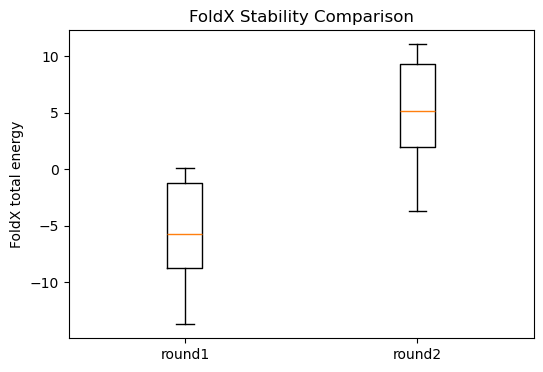

In [284]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

data = [
    combined_foldx_df[combined_foldx_df["round"]=="round1_unconstrained"]["total_energy"],
    combined_foldx_df[combined_foldx_df["round"]=="round2_constrained"]["total_energy"]
]

plt.boxplot(data, labels=["round1", "round2"])
plt.ylabel("FoldX total energy")
plt.title("FoldX Stability Comparison")
plt.show()

***save results***

In [285]:
output_dir = Path("../results/tables")
if not output_dir.exists():
    output_dir = Path("results/tables")

output_dir.mkdir(parents=True, exist_ok=True)

combined_foldx_df.to_csv(output_dir / "round1_vs_round2_foldx_all.csv", index=False)
summary_foldx.to_csv(output_dir / "round1_vs_round2_foldx_summary.csv", index=False)

print("Saved:", output_dir / "round1_vs_round2_foldx_all.csv")
print("Saved:", output_dir / "round1_vs_round2_foldx_summary.csv")

Saved: ../results/tables/round1_vs_round2_foldx_all.csv
Saved: ../results/tables/round1_vs_round2_foldx_summary.csv


## FoldX Stability Analysis

Top AlphaFold structures from the unconstrained and constrained redesign rounds were evaluated with FoldX.

### What was done

- Used repaired AlphaFold structures as FoldX inputs
- Ran FoldX Stability on each repaired structure
- Parsed the final stability output files
- Compared total energies across redesign rounds

### Why this matters

This step adds an energetic perspective to complement AlphaFold confidence and RMSD. It helps assess whether constrained redesign also produces energetically plausible structural models.

### Important limitation

FoldX energies are computational estimates and do not directly prove experimental stability, folding efficiency, or function.

## Step 28 — Final Integrated Candidate Table

In [286]:
import pandas as pd
from pathlib import Path
import os

tables_dir = Path("../results/tables")
if not tables_dir.exists():
    tables_dir = Path("results/tables")

print("Using tables directory:", tables_dir)
print(sorted([p.name for p in tables_dir.glob("*.csv")]))

Using tables directory: ../results/tables
['constraint_positions.csv', 'design_candidates.csv', 'design_validation.csv', 'final_candidate_master_summary.csv', 'final_candidate_master_table.csv', 'mutation_analysis_long.csv', 'mutation_risk_annotated.csv', 'mutation_risk_review_table.csv', 'native_baseline.csv', 'native_vs_top_designs.csv', 'round1_vs_round2_ca_rmsd.csv', 'round1_vs_round2_ca_rmsd_summary.csv', 'round1_vs_round2_constrained_sequences.csv', 'round1_vs_round2_constrained_stats.csv', 'round1_vs_round2_foldx_all.csv', 'round1_vs_round2_foldx_summary.csv', 'round2_constrained_design_comparison.csv', 'round2_validation.csv', 'selected_candidates.csv', 'top3_candidates.csv']


***Load required tables***

In [287]:
round1_df = pd.read_csv(tables_dir / "selected_candidates.csv")
round2_df = pd.read_csv(tables_dir / "round2_constrained_design_comparison.csv")
rmsd_df = pd.read_csv(tables_dir / "round1_vs_round2_ca_rmsd.csv")
foldx_df = pd.read_csv(tables_dir / "round1_vs_round2_foldx_all.csv")

print("round1_df:", round1_df.shape)
print("round2_df:", round2_df.shape)
print("rmsd_df:", rmsd_df.shape)
print("foldx_df:", foldx_df.shape)

round1_df: (5, 11)
round2_df: (11, 6)
rmsd_df: (11, 4)
foldx_df: (11, 6)


***Load AlphaFold tables for both rounds***

In [288]:
round1_af_df = pd.read_csv(tables_dir / "design_validation.csv")
print("round1_af_df:", round1_af_df.shape)

round1_af_df: (6, 9)


In [289]:
round2_af_file = tables_dir / "round2_validation.csv"
print("Round 2 validation exists:", round2_af_file.exists())

Round 2 validation exists: True


In [290]:
round2_af_df = pd.read_csv(round2_af_file)
print("round2_af_df:", round2_af_df.shape)

round2_af_df: (5, 3)


***Helper function***

In [291]:
def clean_text_key(text):
    if pd.isna(text):
        return None
    text = str(text)
    text = text.split("/")[-1]
    text = text.replace(".pdb", "").replace(".json", "").replace(".fa", "").replace(".fasta", "")
    text = text.replace("_Repair", "").replace("_0_ST", "").replace("_ST", "")
    return text

In [292]:
def shorten_round1_score_key(text):
    """
    Convert:
    seq_1_3e80b_scores_rank_001_alphafold2_ptm_model_4_seed_000
    into:
    seq_1_3e80b
    """
    if pd.isna(text):
        return None

    text = clean_text_key(text)
    parts = text.split("_")

    if len(parts) >= 3 and parts[0] == "seq":
        return "_".join(parts[:3])

    return text

In [293]:
round2_df = round2_df.copy()

if "name" in round2_df.columns:
    round2_df["candidate_key"] = round2_df["name"].apply(clean_candidate_key)
elif "id" in round2_df.columns:
    round2_df["candidate_key"] = round2_df["id"].apply(clean_candidate_key)
else:
    round2_df["candidate_key"] = round2_df.index.astype(str)

print(round2_df[["candidate_key"]].head())

  candidate_key
0   1LYZ_clean,
1        T=0.1,
2        T=0.1,
3        T=0.1,
4        T=0.1,


***Prepare round 1 correctly***

In [294]:
round1_df = round1_df.copy()
round1_df["round"] = "round1_unconstrained"

if "file" in round1_df.columns:
    round1_df["candidate_key"] = round1_df["file"].apply(shorten_round1_score_key)
elif "id" in round1_df.columns:
    round1_df["candidate_key"] = round1_df["id"].apply(shorten_round1_score_key)
else:
    raise ValueError("Round 1 table needs 'file' or 'id' column")

print(round1_df[["file", "candidate_key"]].head())

                                                file candidate_key
0  ../results/alphafold/seq_1_3e80b_scores_rank_0...   seq_1_3e80b
1  ../results/alphafold/seq_5_55760_scores_rank_0...   seq_5_55760
2  ../results/alphafold/seq_2_a3008_scores_rank_0...   seq_2_a3008
3  ../results/alphafold/seq_4_01504_scores_rank_0...   seq_4_01504
4  ../results/alphafold/seq_3_76161_scores_rank_0...   seq_3_76161


***Prepare round 1 AlphaFold table***

In [295]:
round1_af_df = round1_af_df.copy()

if "file" in round1_af_df.columns:
    round1_af_df["candidate_key"] = round1_af_df["file"].apply(shorten_round1_score_key)
elif "id" in round1_af_df.columns:
    round1_af_df["candidate_key"] = round1_af_df["id"].apply(shorten_round1_score_key)
else:
    raise ValueError("Round 1 AF table needs 'file' or 'id'")

***Prepare RMSD / FoldX keys***

In [296]:
rmsd_df = rmsd_df.copy()
rmsd_df["structure_key"] = rmsd_df["pdb_file"].apply(clean_text_key)
rmsd_df["candidate_key_round1"] = rmsd_df["structure_key"].apply(shorten_round1_structure_key)

foldx_df = foldx_df.copy()
foldx_df["structure_key"] = foldx_df["structure_name"].apply(clean_text_key)
foldx_df["candidate_key_round1"] = foldx_df["structure_key"].apply(shorten_round1_structure_key)

print(rmsd_df[["structure_key", "candidate_key_round1"]].head())
print(foldx_df[["structure_key", "candidate_key_round1"]].head())

                                       structure_key candidate_key_round1
0  seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_...          seq_0_ce6c6
1  seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_...          seq_1_3e80b
2  seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_...          seq_2_a3008
3  seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_...          seq_3_76161
4  seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_...          seq_4_01504
                                       structure_key candidate_key_round1
0  seq_0_ce6c6_unrelaxed_rank_001_alphafold2_ptm_...          seq_0_ce6c6
1  seq_1_3e80b_unrelaxed_rank_001_alphafold2_ptm_...          seq_1_3e80b
2  seq_2_a3008_unrelaxed_rank_001_alphafold2_ptm_...          seq_2_a3008
3  seq_3_76161_unrelaxed_rank_001_alphafold2_ptm_...          seq_3_76161
4  seq_4_01504_unrelaxed_rank_001_alphafold2_ptm_...          seq_4_01504


***Build round 1 master***

In [297]:
round1_core = round1_df[[
    "round", "candidate_key", "name", "candidate_rank", "sequence",
    "num_mutations", "mutations"
]].copy()

round1_af_core = round1_af_df[["candidate_key", "plddt", "ptm"]].drop_duplicates()

round1_rmsd_core = rmsd_df[rmsd_df["round"] == "round1_unconstrained"][
    ["candidate_key_round1", "ca_rmsd"]
].drop_duplicates()

round1_foldx_core = foldx_df[foldx_df["round"] == "round1_unconstrained"][
    ["candidate_key_round1", "total_energy"]
].drop_duplicates()

round1_master = round1_core.merge(
    round1_af_core,
    on="candidate_key",
    how="left"
)

round1_master = round1_master.merge(
    round1_rmsd_core,
    left_on="candidate_key",
    right_on="candidate_key_round1",
    how="left"
).drop(columns=["candidate_key_round1"])

round1_master = round1_master.merge(
    round1_foldx_core,
    left_on="candidate_key",
    right_on="candidate_key_round1",
    how="left"
).drop(columns=["candidate_key_round1"])

print(round1_master.head())
print(round1_master.shape)

                  round candidate_key  \
0  round1_unconstrained   seq_1_3e80b   
1  round1_unconstrained   seq_5_55760   
2  round1_unconstrained   seq_2_a3008   
3  round1_unconstrained   seq_4_01504   
4  round1_unconstrained   seq_3_76161   

                                                name  candidate_rank  \
0  >T=0.1, sample=1, score=0.8716, global_score=0...               1   
1  >T=0.1, sample=5, score=0.8566, global_score=0...               2   
2  >T=0.1, sample=2, score=0.8667, global_score=0...               3   
3  >T=0.1, sample=4, score=0.8506, global_score=0...               4   
4  >T=0.1, sample=3, score=0.9082, global_score=0...               5   

                                            sequence  num_mutations  \
0  MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...             70   
1  MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...             67   
2  KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...             73   
3  KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAW

***Prepare round 2 correctly***

In [298]:
round2_df = round2_df.copy()
round2_df["round"] = "round2_constrained"

# remove the native-like row if present
round2_df = round2_df[round2_df["num_mutations"] > 0].copy()

round2_df["candidate_key"] = "round2_rank_" + round2_df["candidate_rank"].astype(str)

print(round2_df[["candidate_rank", "candidate_key"]].head())

   candidate_rank  candidate_key
1               2  round2_rank_2
2               3  round2_rank_3
3               4  round2_rank_4
4               5  round2_rank_5
5               6  round2_rank_6


***Prepare round 2 AlphaFold / RMSD / FoldX by evaluated order***

In [299]:
round2_af_df = round2_af_df.copy().sort_values("file").reset_index(drop=True)
round2_rmsd_core = rmsd_df[rmsd_df["round"] == "round2_constrained"].copy().sort_values("pdb_file").reset_index(drop=True)
round2_foldx_core = foldx_df[foldx_df["round"] == "round2_constrained"].copy().sort_values("structure_name").reset_index(drop=True)

print(round2_af_df[["file", "plddt", "ptm"]].head())
print(round2_rmsd_core[["pdb_file", "ca_rmsd"]].head())
print(round2_foldx_core[["structure_name", "total_energy"]].head())

                                                file      plddt   ptm
0  28_18d8e_scores_rank_001_alphafold2_ptm_model_...  97.993256  0.91
1  29_c6257_scores_rank_001_alphafold2_ptm_model_...  97.524341  0.90
2  312_fe3cd_scores_rank_001_alphafold2_ptm_model...  97.055659  0.90
3  31_70f1b_scores_rank_001_alphafold2_ptm_model_...  97.414419  0.90
4  32_78fa0_scores_rank_001_alphafold2_ptm_model_...  97.374264  0.90
                                            pdb_file   ca_rmsd
0  28_18d8e_unrelaxed_rank_001_alphafold2_ptm_mod...  0.726553
1  29_c6257_unrelaxed_rank_001_alphafold2_ptm_mod...  0.738384
2  312_fe3cd_unrelaxed_rank_001_alphafold2_ptm_mo...  0.713334
3  31_70f1b_unrelaxed_rank_001_alphafold2_ptm_mod...  0.683969
4  32_78fa0_unrelaxed_rank_001_alphafold2_ptm_mod...  0.708983
                                      structure_name  total_energy
0  28_18d8e_unrelaxed_rank_001_alphafold2_ptm_mod...      -3.65322
1  29_c6257_unrelaxed_rank_001_alphafold2_ptm_mod...       9.28778
2

***Match them to top round 2 candidates***

In [300]:
n_eval = min(len(round2_af_df), len(round2_rmsd_core), len(round2_foldx_core))
round2_eval = round2_df.sort_values("candidate_rank").head(n_eval).copy().reset_index(drop=True)

round2_eval["candidate_key"] = "round2_rank_" + round2_eval["candidate_rank"].astype(str)
round2_af_df = round2_af_df.head(n_eval).copy()
round2_rmsd_core = round2_rmsd_core.head(n_eval).copy()
round2_foldx_core = round2_foldx_core.head(n_eval).copy()

round2_af_df["candidate_key"] = round2_eval["candidate_key"]
round2_rmsd_core["candidate_key"] = round2_eval["candidate_key"]
round2_foldx_core["candidate_key"] = round2_eval["candidate_key"]

print(round2_eval[["candidate_rank", "candidate_key"]])

   candidate_rank  candidate_key
0               2  round2_rank_2
1               3  round2_rank_3
2               4  round2_rank_4
3               5  round2_rank_5
4               6  round2_rank_6


***Build round 2 master***

In [301]:
round2_master = round2_eval[[
    "round", "candidate_key", "name", "candidate_rank", "sequence",
    "num_mutations", "mutations"
]].copy()

round2_master = round2_master.merge(
    round2_af_df[["candidate_key", "plddt", "ptm"]],
    on="candidate_key",
    how="left"
)

round2_master = round2_master.merge(
    round2_rmsd_core[["candidate_key", "ca_rmsd"]],
    on="candidate_key",
    how="left"
)

round2_master = round2_master.merge(
    round2_foldx_core[["candidate_key", "total_energy"]],
    on="candidate_key",
    how="left"
)

print(round2_master.head())
print(round2_master.shape)

                round  candidate_key    name  candidate_rank  \
0  round2_constrained  round2_rank_2  T=0.1,               2   
1  round2_constrained  round2_rank_3  T=0.1,               3   
2  round2_constrained  round2_rank_4  T=0.1,               4   
3  round2_constrained  round2_rank_5  T=0.1,               5   
4  round2_constrained  round2_rank_6  T=0.1,               6   

                                            sequence  num_mutations  \
0  MVWGQCELAAALKKHGMDNYRGYSLGNFVCLAKFESNFNNSVTNTN...             31   
1  TVWGQCELAAALKKHGMDNFRGYSLGNFVCLAKFESNFNNSVSNTN...             32   
2  KVFGRCELAAALKKHGMDNFRGYSLGNWVCLAKFESNFNTSVSNTN...             28   
3  KVWGTCELAAALKKHGMDNFRGYSLGNYVCLAKFESNFNNSVSNTN...             32   
4  MVFGQCELAAALKKHGMDNFRGYSLGNFVCLAKFESNFNNTVSNTN...             31   

                                           mutations      plddt   ptm  \
0  K1M;F3W;R5Q;M12L;R14K;L17M;W28F;A31L;T40N;Q41S...  97.993256  0.91   
1  K1T;F3W;R5Q;M12L;R14K;L17M;Y20F;W28F;A3

***Combine final master table***

In [302]:
master_df = pd.concat([round1_master, round2_master], ignore_index=True)

final_cols = [
    "round", "candidate_key", "name", "candidate_rank", "sequence",
    "num_mutations", "mutations", "plddt", "ptm", "ca_rmsd", "total_energy"
]

master_df = master_df[final_cols].copy()

print(master_df.head())
print(master_df.shape)

                  round candidate_key  \
0  round1_unconstrained   seq_1_3e80b   
1  round1_unconstrained   seq_5_55760   
2  round1_unconstrained   seq_2_a3008   
3  round1_unconstrained   seq_4_01504   
4  round1_unconstrained   seq_3_76161   

                                                name  candidate_rank  \
0  >T=0.1, sample=1, score=0.8716, global_score=0...               1   
1  >T=0.1, sample=5, score=0.8566, global_score=0...               2   
2  >T=0.1, sample=2, score=0.8667, global_score=0...               3   
3  >T=0.1, sample=4, score=0.8506, global_score=0...               4   
4  >T=0.1, sample=3, score=0.9082, global_score=0...               5   

                                            sequence  num_mutations  \
0  MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...             70   
1  MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...             67   
2  KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...             73   
3  KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAW

***Check missing values***

In [303]:
print("Missing pLDDT:", master_df["plddt"].isna().sum())
print("Missing pTM:", master_df["ptm"].isna().sum())
print("Missing RMSD:", master_df["ca_rmsd"].isna().sum())
print("Missing FoldX:", master_df["total_energy"].isna().sum())

Missing pLDDT: 0
Missing pTM: 0
Missing RMSD: 0
Missing FoldX: 0


In [304]:
master_file = tables_dir / "final_candidate_master_table.csv"
summary_file = tables_dir / "final_candidate_master_summary.csv"

master_df.to_csv(master_file, index=False)

summary_master = (
    master_df.groupby("round")
    .agg(
        n_candidates=("candidate_key", "count"),
        mean_mutations=("num_mutations", "mean"),
        mean_plddt=("plddt", "mean"),
        mean_ptm=("ptm", "mean"),
        mean_rmsd=("ca_rmsd", "mean"),
        mean_foldx=("total_energy", "mean")
    )
    .reset_index()
)

summary_master.to_csv(summary_file, index=False)

print("Saved:", master_file)
print("Saved:", summary_file)
print(summary_master)

Saved: ../results/tables/final_candidate_master_table.csv
Saved: ../results/tables/final_candidate_master_summary.csv
                  round  n_candidates  mean_mutations  mean_plddt  mean_ptm  \
0  round1_unconstrained             5            71.2   94.753054     0.888   
1    round2_constrained             5            30.8   97.472388     0.902   

   mean_rmsd  mean_foldx  
0   0.829452   -6.063698  
1   0.714245    4.756634  


## Final Integrated Candidate Table

All major evaluation metrics were merged into a single candidate-level results table.

### What was integrated

- mutation count and mutation strings
- AlphaFold confidence metrics (pLDDT, pTM)
- C-alpha RMSD
- FoldX total energy

### Why this matters

This step converts the workflow from multiple separate analyses into a decision-ready candidate table. It enables direct comparison of sequence divergence, structural confidence, geometric similarity, and energetic plausibility.

### Important limitation

Some candidate identifiers required manual harmonization because different tools produced different naming conventions.

## Step 29 — Final Ranking Logic and Candidate Selection

In [306]:
import pandas as pd
from pathlib import Path
import os

tables_dir = Path("../results/tables")
if not tables_dir.exists():
    tables_dir = Path("results/tables")

master_file = tables_dir / "final_candidate_master_table.csv"
master_df = pd.read_csv(master_file)

print(master_df.shape)
print(master_df.head())

(10, 11)
                  round candidate_key  \
0  round1_unconstrained   seq_1_3e80b   
1  round1_unconstrained   seq_5_55760   
2  round1_unconstrained   seq_2_a3008   
3  round1_unconstrained   seq_4_01504   
4  round1_unconstrained   seq_3_76161   

                                                name  candidate_rank  \
0  >T=0.1, sample=1, score=0.8716, global_score=0...               1   
1  >T=0.1, sample=5, score=0.8566, global_score=0...               2   
2  >T=0.1, sample=2, score=0.8667, global_score=0...               3   
3  >T=0.1, sample=4, score=0.8506, global_score=0...               4   
4  >T=0.1, sample=3, score=0.9082, global_score=0...               5   

                                            sequence  num_mutations  \
0  MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...             70   
1  MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...             67   
2  KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...             73   
3  KKYSRCELAQTLKKLGMDNFNGYP

In [307]:
print(master_df[["round", "candidate_key", "num_mutations", "plddt", "ptm", "ca_rmsd", "total_energy"]])

                  round  candidate_key  num_mutations      plddt   ptm  \
0  round1_unconstrained    seq_1_3e80b             70  96.237209  0.90   
1  round1_unconstrained    seq_5_55760             67  95.769535  0.89   
2  round1_unconstrained    seq_2_a3008             73  95.363643  0.89   
3  round1_unconstrained    seq_4_01504             70  95.135736  0.89   
4  round1_unconstrained    seq_3_76161             76  91.259147  0.87   
5    round2_constrained  round2_rank_2             31  97.993256  0.91   
6    round2_constrained  round2_rank_3             32  97.524341  0.90   
7    round2_constrained  round2_rank_4             28  97.055659  0.90   
8    round2_constrained  round2_rank_5             32  97.414419  0.90   
9    round2_constrained  round2_rank_6             31  97.374264  0.90   

    ca_rmsd  total_energy  
0  0.784212    -13.692300  
1  0.681965      0.076024  
2  1.094273     -9.198090  
3  0.725156     -7.221200  
4  0.861658     -0.282924  
5  0.726553     -

In [308]:
rank_df = master_df.copy()

def minmax_scale(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series([1.0] * len(series), index=series.index)
    return (series - min_val) / (max_val - min_val)

# Higher is better
rank_df["plddt_score"] = minmax_scale(rank_df["plddt"])
rank_df["ptm_score"] = minmax_scale(rank_df["ptm"])

# Lower is better → reverse scale
rank_df["mutation_score"] = 1 - minmax_scale(rank_df["num_mutations"])
rank_df["rmsd_score"] = 1 - minmax_scale(rank_df["ca_rmsd"])
rank_df["foldx_score"] = 1 - minmax_scale(rank_df["total_energy"])

print(rank_df[[
    "candidate_key", "plddt_score", "ptm_score",
    "mutation_score", "rmsd_score", "foldx_score"
]].head())

  candidate_key  plddt_score  ptm_score  mutation_score  rmsd_score  \
0   seq_1_3e80b     0.739231       0.75          0.1250    0.752013   
1   seq_5_55760     0.669782       0.50          0.1875    1.000000   
2   seq_2_a3008     0.609508       0.50          0.0625    0.000000   
3   seq_4_01504     0.575665       0.50          0.1250    0.895245   
4   seq_3_76161     0.000000       0.00          0.0000    0.564178   

   foldx_score  
0     1.000000  
1     0.443265  
2     0.818273  
3     0.738335  
4     0.457780  


In [309]:
weights = {
    "plddt_score": 0.25,
    "ptm_score": 0.20,
    "mutation_score": 0.20,
    "rmsd_score": 0.20,
    "foldx_score": 0.15
}

In [310]:
rank_df["final_score"] = (
    weights["plddt_score"] * rank_df["plddt_score"] +
    weights["ptm_score"] * rank_df["ptm_score"] +
    weights["mutation_score"] * rank_df["mutation_score"] +
    weights["rmsd_score"] * rank_df["rmsd_score"] +
    weights["foldx_score"] * rank_df["foldx_score"]
)

rank_df = rank_df.sort_values("final_score", ascending=False).reset_index(drop=True)

print(rank_df[[
    "round", "candidate_key", "candidate_rank", "num_mutations",
    "plddt", "ptm", "ca_rmsd", "total_energy", "final_score"
]])

                  round  candidate_key  candidate_rank  num_mutations  \
0    round2_constrained  round2_rank_2               2             31   
1    round2_constrained  round2_rank_4               4             28   
2    round2_constrained  round2_rank_6               6             31   
3    round2_constrained  round2_rank_5               5             32   
4    round2_constrained  round2_rank_3               3             32   
5  round1_unconstrained    seq_1_3e80b               1             70   
6  round1_unconstrained    seq_5_55760               2             67   
7  round1_unconstrained    seq_4_01504               4             70   
8  round1_unconstrained    seq_2_a3008               3             73   
9  round1_unconstrained    seq_3_76161               5             76   

       plddt   ptm   ca_rmsd  total_energy  final_score  
0  97.993256  0.91  0.726553     -3.653220     0.904980  
1  97.055659  0.90  0.713334      1.971990     0.804966  
2  97.374264  0.90  0.

In [311]:
top_candidates_df = rank_df.head(3).copy()

print(top_candidates_df[[
    "round", "candidate_key", "candidate_rank", "num_mutations",
    "plddt", "ptm", "ca_rmsd", "total_energy", "final_score"
]])

                round  candidate_key  candidate_rank  num_mutations  \
0  round2_constrained  round2_rank_2               2             31   
1  round2_constrained  round2_rank_4               4             28   
2  round2_constrained  round2_rank_6               6             31   

       plddt   ptm   ca_rmsd  total_energy  final_score  
0  97.993256  0.91  0.726553      -3.65322     0.904980  
1  97.055659  0.90  0.713334       1.97199     0.804966  
2  97.374264  0.90  0.708983       5.13842     0.787199  


In [312]:
ranked_file = tables_dir / "final_candidate_ranking.csv"
top_file = tables_dir / "top_final_candidates.csv"

rank_df.to_csv(ranked_file, index=False)
top_candidates_df.to_csv(top_file, index=False)

print("Saved:", ranked_file)
print("Saved:", top_file)

Saved: ../results/tables/final_candidate_ranking.csv
Saved: ../results/tables/top_final_candidates.csv


In [313]:
filtered_df = rank_df[
    (rank_df["plddt"] >= 95) &
    (rank_df["ptm"] >= 0.89) &
    (rank_df["ca_rmsd"] <= 0.80)
].copy()

filtered_df = filtered_df.sort_values(
    ["num_mutations", "total_energy"],
    ascending=[True, True]
).reset_index(drop=True)

print(filtered_df[[
    "round", "candidate_key", "candidate_rank", "num_mutations",
    "plddt", "ptm", "ca_rmsd", "total_energy", "final_score"
]])

                  round  candidate_key  candidate_rank  num_mutations  \
0    round2_constrained  round2_rank_4               4             28   
1    round2_constrained  round2_rank_2               2             31   
2    round2_constrained  round2_rank_6               6             31   
3    round2_constrained  round2_rank_3               3             32   
4    round2_constrained  round2_rank_5               5             32   
5  round1_unconstrained    seq_5_55760               2             67   
6  round1_unconstrained    seq_1_3e80b               1             70   
7  round1_unconstrained    seq_4_01504               4             70   

       plddt   ptm   ca_rmsd  total_energy  final_score  
0  97.055659  0.90  0.713334      1.971990     0.804966  
1  97.993256  0.91  0.726553     -3.653220     0.904980  
2  97.374264  0.90  0.708983      5.138420     0.787199  
3  97.524341  0.90  0.738384      9.287780     0.749174  
4  97.414419  0.90  0.683969     11.038200     0.760

## Final Ranking Logic and Candidate Selection

A multi-metric scoring system was used to rank redesign candidates.

### Metrics included

- mutation burden
- AlphaFold confidence (pLDDT, pTM)
- C-alpha RMSD
- FoldX total energy

### Why this matters

No single metric is sufficient to evaluate a redesigned protein. This ranking step integrates structural confidence, geometric similarity, energetic plausibility, and sequence divergence into a decision-ready framework.

### Important limitation

The final score depends on the chosen metric weights and should be interpreted as a practical ranking heuristic rather than absolute truth.